----
# **Week 2: Data Visualization & Communication**
----

In [2]:
if (!require("palmerpenguins")) install.packages("palmerpenguins")
library(palmerpenguins)
library(tidyverse)

Loading required package: palmerpenguins

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘palmerpenguins’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘palmerpenguins’


The following objects are masked from ‘package:datasets’:

    penguins, penguins_raw




## Baseline dataset cleaning

In [3]:
data_clean <- as.data.frame(penguins) %>%
  drop_na(bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g)
data_clean$sex <- as.character(data_clean$sex)
data_clean$sex[is.na(data_clean$sex)] <- "Unknown"
data_clean$sex <- as.factor(data_clean$sex)

---
### **Chart 1: Scatter Plot with Linear Trendlines (Simpson's Paradox)**

`geom_smooth()` using formula = 'y ~ x'


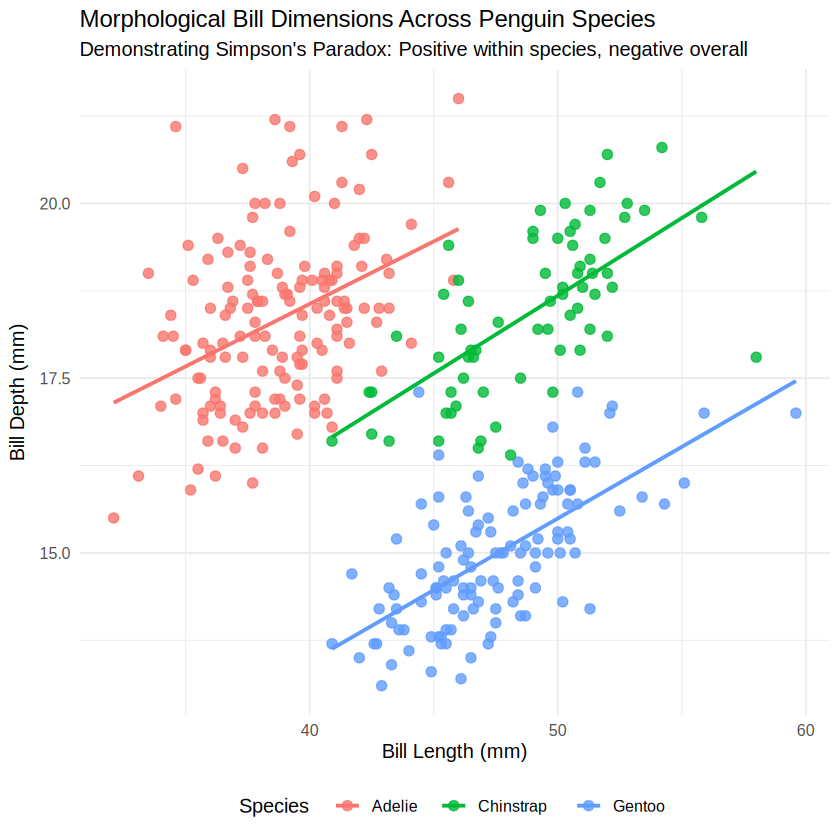

In [4]:
p1 <- ggplot(data_clean, aes(x = bill_length_mm, y = bill_depth_mm, color = species)) +
  geom_point(alpha = 0.8, size = 2.5) +
  geom_smooth(method = "lm", se = FALSE, linewidth = 1.1) +
  labs(
    title = "Morphological Bill Dimensions Across Penguin Species",
    subtitle = "Demonstrating Simpson's Paradox: Positive within species, negative overall",
    x = "Bill Length (mm)",
    y = "Bill Depth (mm)",
    color = "Species"
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = "bottom")

print(p1)

---
### **Chart 2: Histogram & Density Distribution**

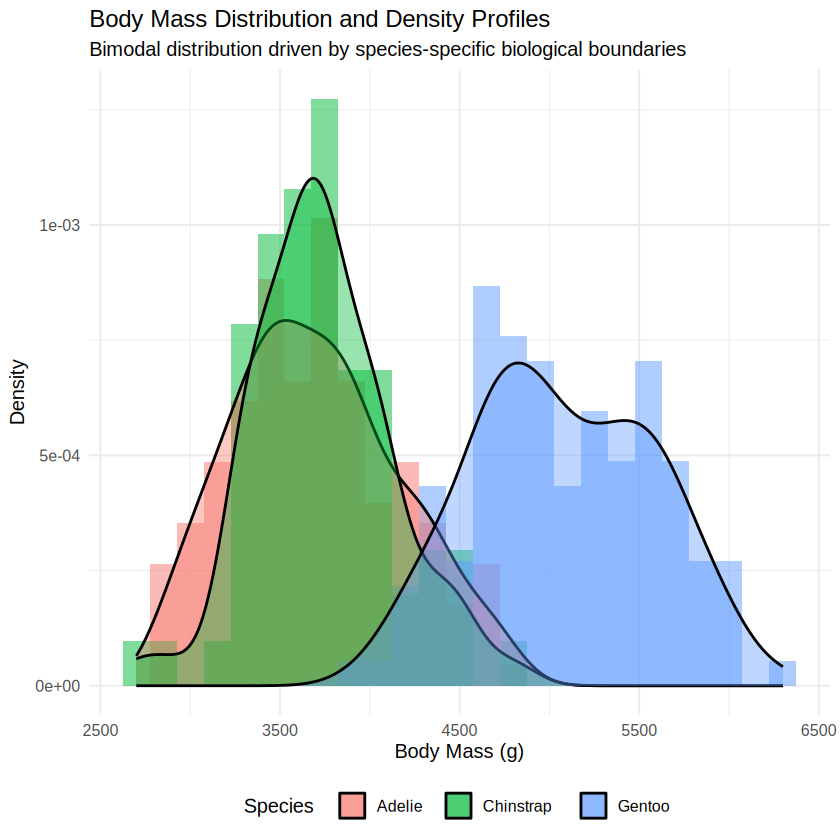

In [5]:
p2 <- ggplot(data_clean, aes(x = body_mass_g, fill = species)) +
  geom_histogram(aes(y = after_stat(density)), bins = 25, alpha = 0.5, position = "identity") +
  geom_density(alpha = 0.4, linewidth = 0.8) +
  labs(
    title = "Body Mass Distribution and Density Profiles",
    subtitle = "Bimodal distribution driven by species-specific biological boundaries",
    x = "Body Mass (g)",
    y = "Density",
    fill = "Species"
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = "bottom")

print(p2)

---
### **Chart 3: Faceted Bar Chart (Cross-Demographic Analysis)**

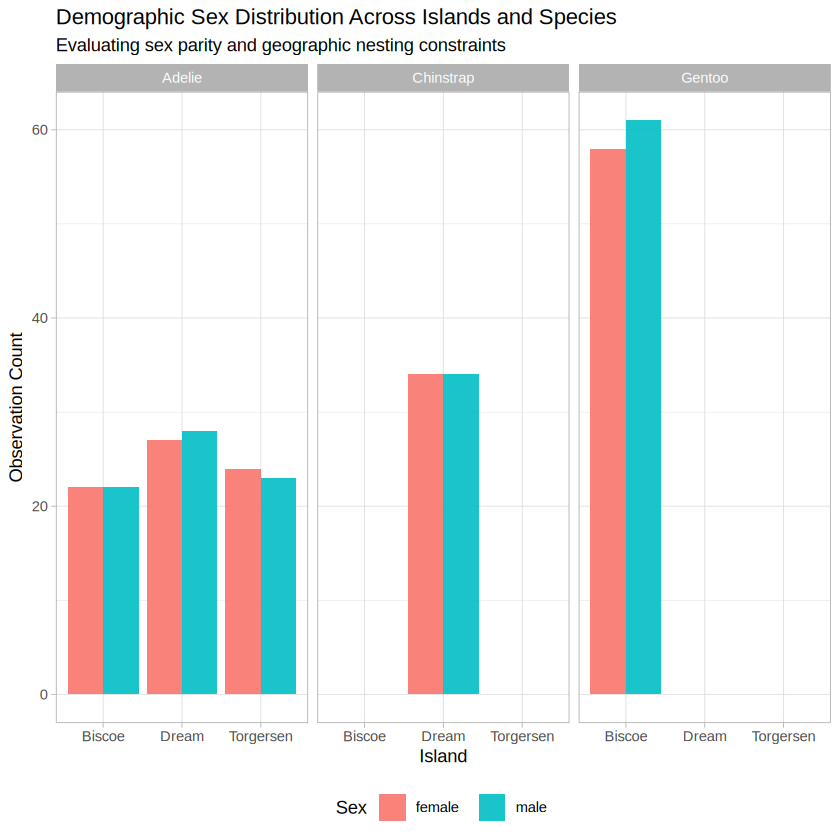

In [6]:
p3 <- ggplot(filter(data_clean, sex != "Unknown"), aes(x = island, fill = sex)) +
  geom_bar(position = "dodge", alpha = 0.9) +
  facet_wrap(~ species) +
  labs(
    title = "Demographic Sex Distribution Across Islands and Species",
    subtitle = "Evaluating sex parity and geographic nesting constraints",
    x = "Island",
    y = "Observation Count",
    fill = "Sex"
  ) +
  scale_fill_manual(values = c("female" = "#F8766D", "male" = "#00BFC4")) +
  theme_light(base_size = 11) +
  theme(legend.position = "bottom")

print(p3)

---
### **Chart 4: Longitudinal Line Chart with Error Margins**

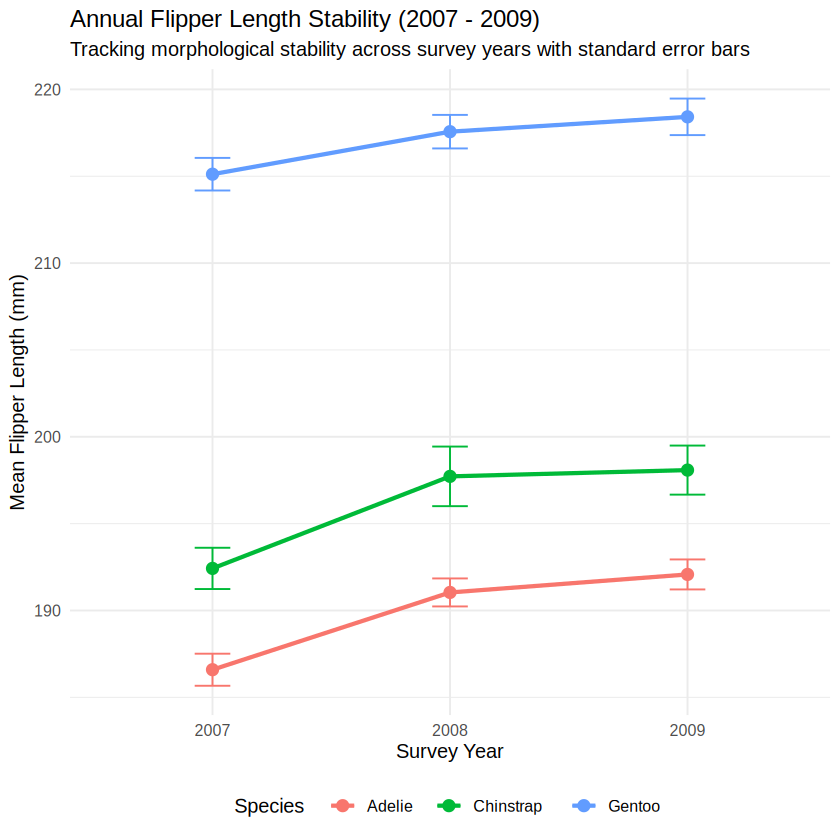

In [7]:
yearly_trend <- data_clean %>%
  group_by(year, species) %>%
  summarize(
    mean_flipper = mean(flipper_length_mm),
    se_flipper = sd(flipper_length_mm) / sqrt(n()),
    .groups = "drop"
  )

p4 <- ggplot(yearly_trend, aes(x = factor(year), y = mean_flipper, group = species, color = species)) +
  geom_line(linewidth = 1.2) +
  geom_point(size = 3) +
  geom_errorbar(aes(ymin = mean_flipper - se_flipper, ymax = mean_flipper + se_flipper), width = 0.15) +
  labs(
    title = "Annual Flipper Length Stability (2007 - 2009)",
    subtitle = "Tracking morphological stability across survey years with standard error bars",
    x = "Survey Year",
    y = "Mean Flipper Length (mm)",
    color = "Species"
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = "bottom")

print(p4)